In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dask.distributed import Client
import sys

In [2]:
client = Client(
    n_workers=24,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40501,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35689,Total threads: 1
Dashboard: /proxy/32951/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:35135,


In [ ]:
YEAR = "2020"

In [3]:
def open_files(root_path, preprocess=None):
    files = [f for f in root_path.rglob('*.nc')]

    return xr.open_mfdataset(
        files,
        preprocess = preprocess,
        concat_dim='time',
        combine='nested',
        data_vars='minimal',
        coords='minimal',
        compat='override',
        parallel=True,
        chunks='auto'
    )

In [4]:
###########################################################################
# Surface Solar Irradiance product based on Himawari observations
###########################################################################

him_path = Path(f"data/raw/himawari-solar/p1h/v1.1/{YEAR}")
him_files = [f for f in him_path.rglob('*.nc')]

def preprocess(ds):
    return ds[['hourly_integral_of_surface_global_irradiance']]

him_ds = open_files(him_path, preprocess=preprocess)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/pyth

In [ ]:
###########################################################################
# Load and preprocess weather features
###########################################################################

base_path = Path("data/raw/weatherfeatures")

weather_features = [
    ("wcb", "TOTAL"),
    ("maxcl", "FLAG"),
    ("mincl", "INPUT"),
    ("cutoff", "TROPO"),
    ("fronts", "FRONT"),
    ("jets", "jet"),
    ("pvstreamer", "TROP"),
]

ds_list = []
for wf, var_name in weather_features:

    # get correct directory name for file path
    if wf == "wcb":
        cdf = "cdf.1hourly"
    elif wf == "fronts":
        cdf = "cdf.850hPa"
    else:
        cdf = "cdf"

    
    def preprocess(ds):

        # rename variable to identify it with the weather feature
        ds = ds.rename({var_name: wf})
        ds = ds[[wf]] # keep just the one var

        # rename dimensions to  "latitude" and "longitude"
        rename_dict = {}
        for dim in ds.dims:
            lower = dim.lower()
    
            if "lat" in lower or "dimy" in lower:
                rename_dict[dim] = "latitude"
    
            elif "lon" in lower or "dimx" in lower:
                rename_dict[dim] = "longitude"

            # sum over mutiple heights to get single height
            elif "dimz" in lower:
                ds = ds.sum(dim)


        ds = ds.rename(rename_dict)

        # make sure lat/lon use geographic coordinates
        ny = ds.sizes['latitude']
        nx = ds.sizes['longitude']
        
        latitude = np.linspace(-90, 90, ny)
        longitude = np.linspace(-180, 180, nx)
        
        ds = ds.assign_coords(
            latitude=("latitude", latitude),
            longitude=("longitude", longitude)
        )

        if ny != 721:
            ds = ds.interp(
                latitude=np.linspace(-90, 90, 361),
                longitude=np.linspace(-180, 180, 721),
                method='nearest'
            )
                
        return ds

    
    wf_dir = base_path / wf / cdf / YEAR
    ds = open_files(wf_dir, preprocess=preprocess)

    ds_list.append(ds)

wf_ds = xr.merge(ds_list)

wf_ds_aus = wf_ds.sel(
    latitude=slice(him_ds.latitude.min(), him_ds.latitude.max()),
    longitude=slice(him_ds.longitude.min(), him_ds.longitude.max())
)

In [51]:
him_ds = him_ds.assign_coords(
    time=("time", him_ds.time.dt.floor("H").values),
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/core/accessor_dt.py:165: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


In [ ]:
him_ds, wf_ds_aus = xr.align(
    him_ds,
    wf_ds_aus,
    join='inner'
)

him_ds = him_ds.interp(
    latitude=wf_ds_aus.latitude,
    longitude=wf_ds_aus.longitude,
    method='linear'
)

In [12]:
mask = wcb_ds.TOTAL.compute()

In [13]:
wcb_ghi = him_ds.hourly_integral_of_surface_global_irradiance.where(mask).mean("time").compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 51.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [16]:
wcb_ghi.to_netcdf('/scratch/er8/cd3022/weather-features/wcb_ghi_2020.nc')

In [6]:
wcb_ghi = xr.open_dataset('/scratch/er8/cd3022/weather-features/wcb_ghi_2020.nc')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [18]:
wcb_count = mask.sum('time')

In [21]:
wcb_count.to_netcdf('/scratch/er8/cd3022/weather-features/wcb_count_2020.nc')

In [7]:
wcb_count = xr.open_dataset('/scratch/er8/cd3022/weather-features/wcb_count_2020.nc')

In [32]:
wcb_ghi = wcb_ghi * (1_000_000 / 3600)

In [35]:
him_mask = wcb_ghi.hourly_integral_of_surface_global_irradiance.notnull()

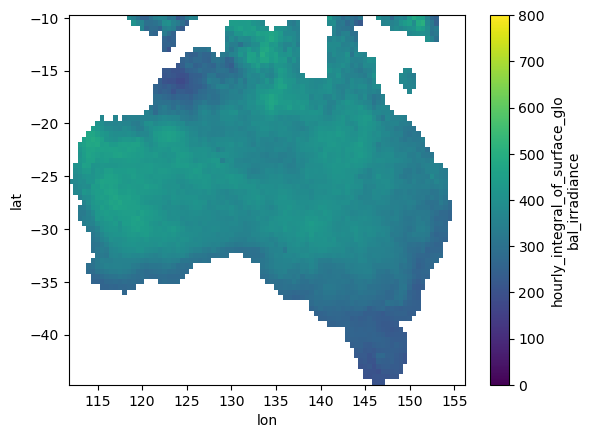

In [95]:
wcb_ghiX.hourly_integral_of_surface_global_irradiance.plot(vmax=800, vmin=0)

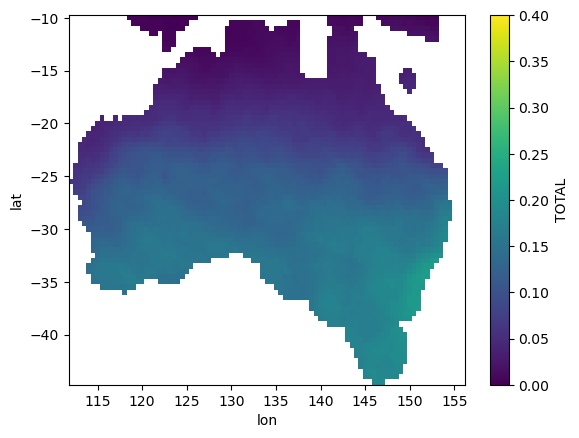

In [91]:
(wcb_count.where(him_mask).TOTAL / him_ds.sizes['time']).plot(vmax=0.4, vmin=0)

In [43]:
ny = maxcl_ds.dims["lat"]
nx = maxcl_ds.dims["lon"]

lat = np.linspace(-90, 90, ny)
lon = np.linspace(-180, 180, nx)

maxcl_ds = maxcl_ds.assign_coords(
    lat=("lat", lat),
    lon=("lon", lon)
)

/jobfs/170607726.gadi-pbs/ipykernel_2249860/1110218173.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ny = maxcl_ds.dims["lat"]
/jobfs/170607726.gadi-pbs/ipykernel_2249860/1110218173.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nx = maxcl_ds.dims["lon"]


In [ ]:
maxcl_ds = maxcl_ds.sel(
    lat=slice(him_ds.latitude.min(), him_ds.latitude.max()),
    lon=slice(him_ds.longitude.min(), him_ds.longitude.max())
)

him_ds, maxcl_ds = xr.align(
    him_ds,
    maxcl_ds,
    join='inner'
)

him_ds = him_ds.interp(
    latitude=maxcl_ds.lat,
    longitude=maxcl_ds.lon,
    method='linear'
)

maxcl_mask = maxcl_ds.FLAG.compute()

maxcl_ghi = him_ds.hourly_integral_of_surface_global_irradiance.where(maxcl_mask).mean("time").compute()

maxcl_ghi = maxcl_ghi * (1_000_000 / 3600)

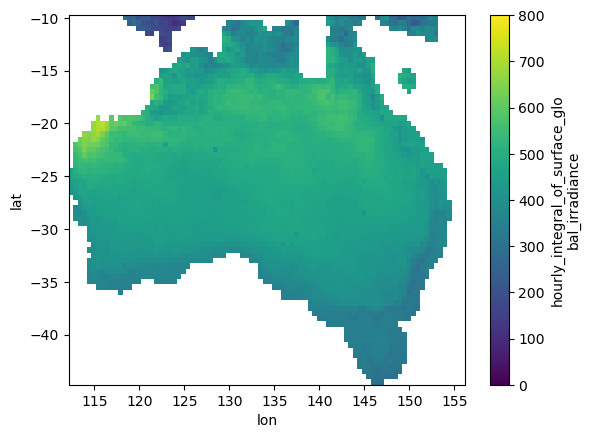

In [94]:
maxcl_ghi.plot(vmax=800, vmin=0)

In [60]:
maxcl_count = maxcl_ds.FLAG.sum('time').compute()

In [66]:
maxcl_count

<xarray.DataArray 'FLAG' (lat: 70, lon: 88)> Size: 49kB
array([[1308., 1309., 1299., ..., 2152., 2153., 2175.],
       [1423., 1412., 1407., ..., 2225., 2236., 2249.],
       [1528., 1521., 1517., ..., 2298., 2313., 2319.],
       ...,
       [  21.,   21.,   21., ...,   27.,   28.,   26.],
       [  21.,   21.,   23., ...,   31.,   29.,   27.],
       [  32.,   30.,   31., ...,   37.,   32.,   29.]])
Coordinates:
  * lat      (lat) float64 560B -44.5 -44.0 -43.5 -43.0 ... -11.0 -10.5 -10.0
  * lon      (lon) float64 704B 112.4 112.9 113.4 113.9 ... 155.0 155.5 156.0

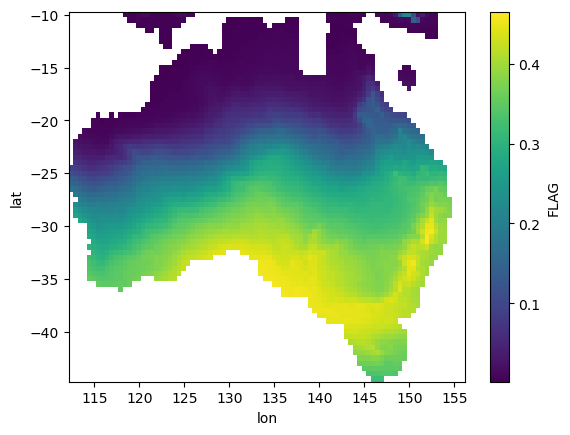

In [68]:
(maxcl_count.where(maxcl_ghi.notnull()) / him_ds.sizes['time']).plot()

In [70]:
ny = mincl_ds.dims["lat"]
nx = mincl_ds.dims["lon"]

lat = np.linspace(-90, 90, ny)
lon = np.linspace(-180, 180, nx)

mincl_ds = mincl_ds.assign_coords(
    lat=("lat", lat),
    lon=("lon", lon)
)

/jobfs/170607726.gadi-pbs/ipykernel_2249860/1066642723.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ny = mincl_ds.dims["lat"]
/jobfs/170607726.gadi-pbs/ipykernel_2249860/1066642723.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nx = mincl_ds.dims["lon"]


In [74]:
mincl_ds = mincl_ds.sel(
    lat=slice(him_ds.latitude.min(), him_ds.latitude.max()),
    lon=slice(him_ds.longitude.min(), him_ds.longitude.max())
)

him_ds, mincl_ds = xr.align(
    him_ds,
    mincl_ds,
    join='inner'
)

him_ds = him_ds.interp(
    lat=mincl_ds.lat,
    lon=mincl_ds.lon,
    method='linear'
)

mincl_mask = mincl_ds.INPUT.compute()

mincl_ghi = him_ds.hourly_integral_of_surface_global_irradiance.where(mincl_mask).mean("time").compute()

mincl_ghi = mincl_ghi * (1_000_000 / 3600)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 52.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [77]:
mincl_ghi = mincl_ghi.isel(dimz_INPUT=0)

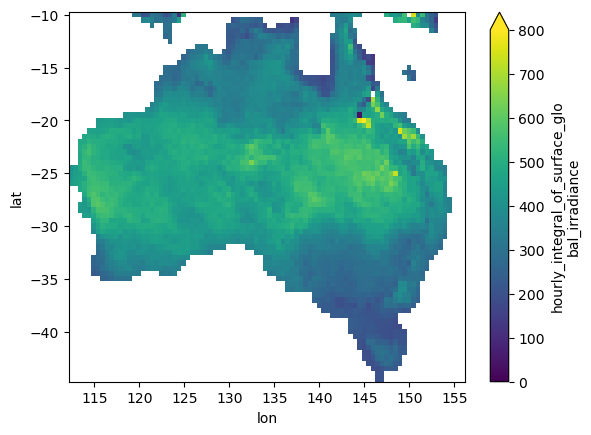

In [92]:
mincl_ghi.plot(vmax=800, vmin=0)

In [80]:
mincl_count = mincl_ds.INPUT.sum("time").compute()

In [82]:
mincl_count = mincl_count.isel(dimz_INPUT=0)

In [89]:
him_ds.sizes['time']

6216

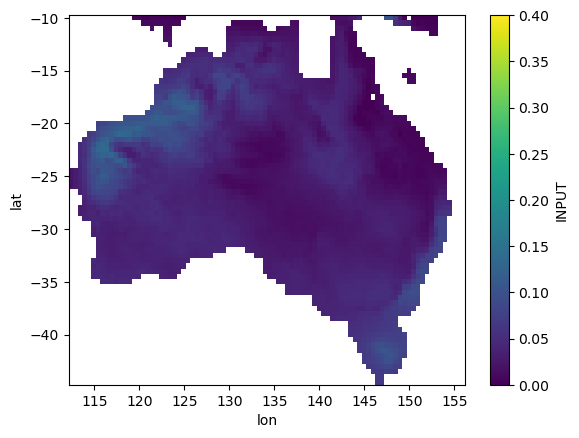

In [93]:
(mincl_count.where(mincl_ghi.notnull()) / him_ds.sizes['time']).plot(vmax=0.4, vmin=0)